# 五分

In [1]:
# %pip install matplotlib

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
import textwrap
from IPython.display import display
from IPython.display import Markdown
from datetime import datetime
import numpy_financial as npf
import math
import pandas as pd
import numpy as np

# 計算 irr

In [3]:
def calculate_irr(signal, threshold):
    # [日期, 評分, 價格]
    hold = 0  # 持有的股數
    balance_in = []  # 每月投入的資金
    balance_total = 0
    month = 1
    this_month_in = 0

    for idx, item in enumerate(signal):
        score = float(item[1])
        price = float(signal[idx][2])
        if score > threshold:
            balance_total += score * 1000  # 買入分數*1000等值的股票
            hold = hold + ((score * 1000) / price)  # 計算持有的股票數

            # 計算每月投入金額
            date_obj = datetime.strptime(item[0], '%Y%m%d')
            if month == date_obj.month:
                this_month_in += score * 1000
            elif month != date_obj.month:
                month = date_obj.month
                this_month_in += score * 1000
                balance_in.append(-this_month_in)
                this_month_in = 0

    balance_in.append(-this_month_in)
    last_price = float(signal[len(signal) - 1][2])
    
    balance_in.append(hold * last_price)
    # print(balance_in)
    irr = npf.irr(balance_in)

    if math.isnan(irr):
        irr = 0

    if balance_total > 0:
        bnh = last_price / float(signal[0][2])
    else:
        bnh = 0

    return round(irr, 5), round(bnh, 5)

In [4]:
def calculate_rtn(signal, threshold):
    # [日期, 評分, 價格]
    hold = 0  # 持有的股數
    retrun = []  # 每月投入的資金
    balance_total = 1000000
    buynhold = []

    for idx, item in enumerate(signal):
        score = float(item[1])
        if idx+1 == len(signal):
            break
        price = float(signal[idx+1][2])
        buynhold.append(price/float(signal[0][2]))

        if score > threshold:
            balance_buy = ((score)/100) * balance_total  # 買入與分數相同百分比的股票
            new_hold = (balance_buy / price)  # 計算持有的股票數
            
            diff = hold - new_hold
            balance_total += diff*price
            hold = new_hold
        
        retrun.append((balance_total + hold*price)/1000000)
        # print(balance_total, hold*price)
    
    balance_total += hold*price

    plt.plot(retrun, label=f'strategy', color='red')
    plt.plot(buynhold, label='buy and hold', color='blue')
    plt.legend()
    plt.show()

    rtn = balance_total/1000000

    if balance_total > 0:
        bnh = float(signal[len(signal)-1][2]) / float(signal[0][2])
    else:
        bnh = 0

    return round(rtn, 5), round(bnh, 5)

# 抓到報酬率

0.024806
0.025248
0.06996
0.06781
0.040444
0.09724600000000001
0.067966
0.09936199999999999
0.023486
0.048566
0.061958
0.05351800000000001
0.056132
0.082496
0.07887200000000001
0.01881
0.055062
0.079498
0.03906
0.027193999999999996
0.040784
0.050496
0.058118
0.05417799999999999
0.04655
0.05142
0.032389999999999995
0.039182
0.05912600000000001
0.049712
0.103324
0.096562
0.078606
0.062822
0.038518000000000004
0.033858
0.013316
0.03469
0.030823999999999997
0.019184
0.09269400000000001
0.04664
0.0493
0.045700000000000005
0.09413800000000001
0.049104
0.06745599999999999
0.018182
0.04623


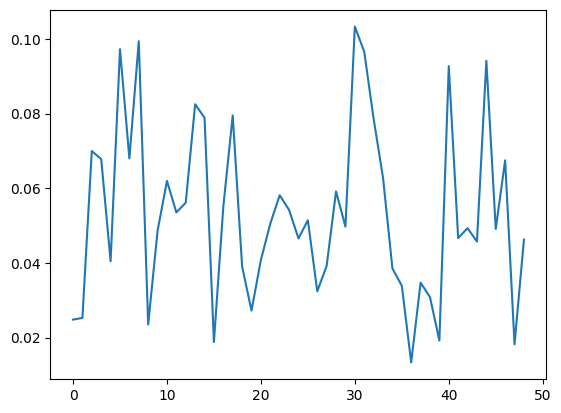

In [77]:
# 20 ~ 51 -100~100
# 88 ~ 137 -100~100
# 157 ~ 235 #非常好(2) #好(1) #無關(0) #不好(-1) #非常不好(-2)

# 20230101 ~ 20231231 一年前5擋股票報酬率 1.405046
# 20230101 ~ 20231231 一年後5擋股票報酬率 1.5045
# 20220101 ~ 20231231 兩年的10擋股票報酬率 1.186132
# 20230101 ~ 20231231 一年的10擋股票報酬率 1.170022

import matplotlib.pyplot as plt
import ast
list_2 = []

for i in range(88, 137):
    acc_list = []
    bnhs = []
    eval_list = []

    with open("eval_gemini/output"+str(i), "r", encoding='utf-8') as f:
        data = f.read()
        list_2.append(float(data.split("平均內部報酬率:")[1].split("，平均總額投入")[0])) 
        print(float(data.split("平均內部報酬率:")[1].split("，平均總額投入")[0]))
        eval_list = ast.literal_eval(data.split("原始數據")[1])

plt.plot(list_2)